# Jupyter Notebook
# Lecture 19 - PCA 


In [58]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time

import seaborn as sns

# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# 1. PCA on Penguins
![Palmer Penguins Picture](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)

*Artwork by @allison_horst*


For this lab, we are going to again use the <a href = "https://allisonhorst.github.io/palmerpenguins/">Palmer Penguins</a> data set by Allison Horst, Alison Hill, and Kristen Gorman. You should have done this in a previous notebook, but if you don't have the package installed to get the data, you can run 
```
pip install palmerpenguins
```
to have access to the data. 

In [59]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins = penguins.dropna()

#Shuffle the data
# penguins = penguins.sample(frac=1)
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Before we get to the full version, let's just take a look at two of the columns: flipper length and bill length. A nice thing we can do is to also color the data by which species label the data point has. 

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

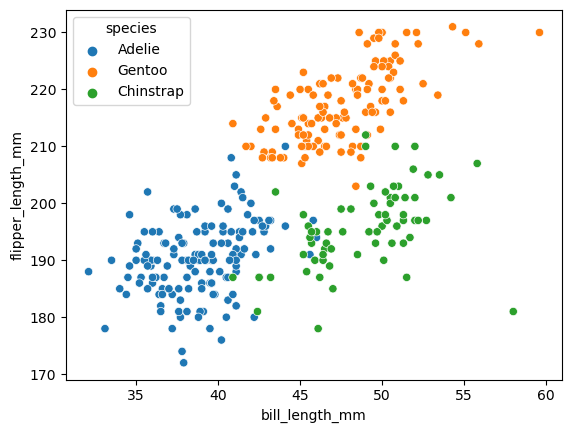

In [60]:
sns.scatterplot(x = penguins.bill_length_mm, 
                y = penguins.flipper_length_mm, 
                hue = penguins.species)

Before we get to it, we're going to just work with the columns that are numeric.  

In [61]:
penguins_num = penguins.select_dtypes(np.number)
penguins_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007
1,39.5,17.4,186.0,3800.0,2007
2,40.3,18.0,195.0,3250.0,2007
4,36.7,19.3,193.0,3450.0,2007
5,39.3,20.6,190.0,3650.0,2007


We will also use mean centered data to make the visualization easier (meaning shifting our data to have mean 0 in every column, and have standard deviation 1). 

In [62]:
p_normalized = (penguins_num - penguins_num.mean())/penguins_num.std()
p_normalized.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,-0.894695,0.779559,-1.424608,-0.567621,-1.281813
1,-0.821552,0.119404,-1.067867,-0.505525,-1.281813
2,-0.675264,0.424091,-0.425733,-1.188572,-1.281813
4,-1.333559,1.084246,-0.568429,-0.940192,-1.281813
5,-0.858123,1.744400,-0.782474,-0.691811,-1.281813


## PCA with just two input columns

To try to draw pictures similar to what we just saw on the slides, we'll first focus on two of the columns. 

In [63]:
penguins_subset2 = p_normalized[['bill_length_mm', 'flipper_length_mm']]
penguins_subset2

,bill_length_mm,flipper_length_mm
0,-0.894695,-1.424608
1,-0.821552,-1.067867
2,-0.675264,-0.425733
4,-1.333559,-0.568429
5,-0.858123,-0.782474
...,...,...
339,2.159064,0.430446
340,-0.090112,0.073705
341,1.025333,-0.568429
342,1.244765,0.644491


We run PCA using the `PCA` command from `scikitlearn`.

In [64]:
from sklearn.decomposition import PCA

In [65]:
# Set up the PCA object
pca = PCA(n_components=2)

# Fit it using our data
pca.fit(penguins_subset2.values)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

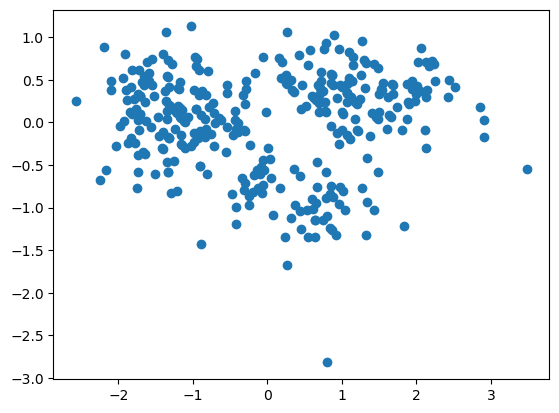

In [66]:
pca_df = pca.fit_transform(penguins_subset2.values)
plt.scatter(pca_df[:,0], pca_df[:,1])

The `pca.components_` store information about the lines we are going to project our data onto. Specifically, each row gives us one of these lines.

In [67]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

(-2.4261469084390352,
 3.105364257468495,
 -2.2772189966421617,
 3.254292169265369)

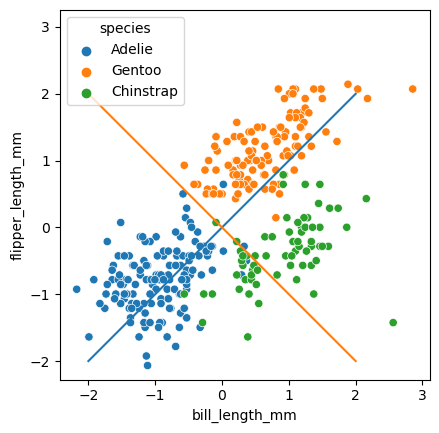

In [68]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)

for i, comp in enumerate(pca.components_):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))
    
plt.axis('square')

A common way to look at the relative importance of the PC's is to draw these components as vectors with length based on the explained variance. 

In [69]:
pca.explained_variance_

array([1.65309564, 0.34690436])

(-2.4261469084390352,
 3.105364257468495,
 -2.2772189966421617,
 3.254292169265369)

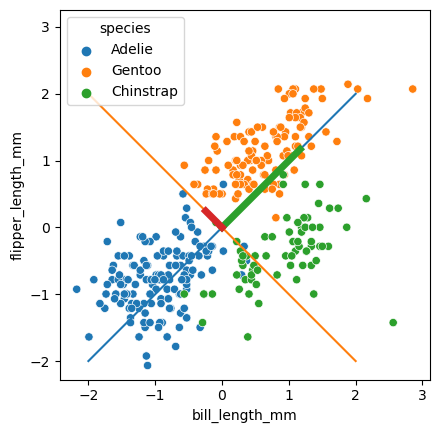

In [70]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)

for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))
    
    comp = comp * var  # scale component by its variance explanation power
    plt.plot(
        [0, comp[0]],
        [0, comp[1]],
        label=f"Component {i}",
        linewidth=5,
        color=f"C{i + 2}",
    )

plt.axis('square')

The next important part are the PC's, which we can get from the `pca` object as follows. I'm going to put them in a dataframe to make drawing and visualization easier. Basically, $PC_1$ is our $Z_1$ in the slides, and $PC_2$ is the $Z_2$.

In [71]:
# The transform function takes in bill,flipper data points, 
# and returns a PC1,PC2 coordinate for each one. 
penguins_pca = pca.fit_transform(penguins_subset2)
penguins_pca = pd.DataFrame(data = penguins_pca, columns = ['PC1', 'PC2'])
penguins_pca.shape

(333, 2)

In [72]:
penguins.species

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object

This is the scatterplot of the data points transformed into the PC space. 

<Axes: xlabel='PC1', ylabel='PC2'>

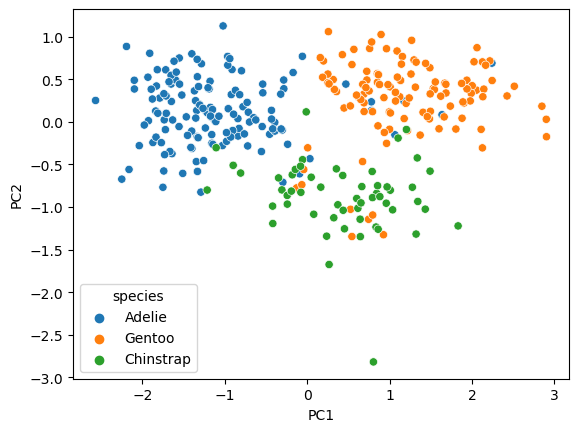

In [73]:
sns.scatterplot(data = penguins_pca, x = 'PC1', y = 'PC2',hue = penguins.species)

&#9989; **<font color=red>Do this:</font>** What are the PC coordinates for the first data point (index 0)?  Which quadrant would this point be drawn in? 


In [74]:
##ANSWER## 
penguins_pca.iloc[0]
# This would be in the 2nd quadrant (up left)

PC1   -1.639995
PC2   -0.374705
Name: 0, dtype: float64


The PC's can be thought of as how far along their associated line the point would be projected. Here's one way to draw all the projections. 

(-2.4261469084390352,
 3.105364257468495,
 -2.2932134979887167,
 3.238297667918814)

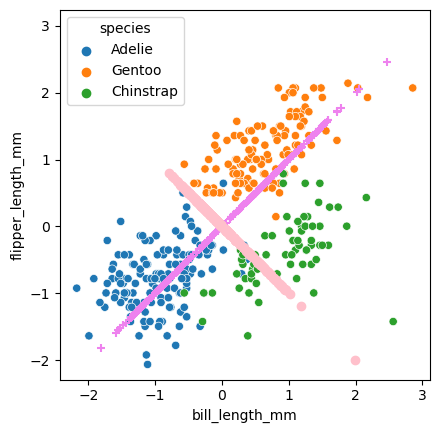

In [75]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)


# Show points projected onto the 1st PC line
X1 = penguins_pca.PC1*pca.components_[0,0]
Y1 = penguins_pca.PC1*pca.components_[0,1]

plt.scatter(X1,Y1, marker = '+', color = 'violet')


# Show points projected onto the 2st PC line
X2 = penguins_pca.PC2*pca.components_[1,0]
Y2 = penguins_pca.PC2*pca.components_[1,1]

plt.scatter(X2,Y2, marker = 'o', color = 'pink')
plt.axis('square')

Below is code that emphasizes the projected points. 

&#9989; **<font color=red>Do this:</font>** the value of `index` below is just picking out a different point in our data set.  Mess around with this number. How do the X and star points move around as you change `index`? 

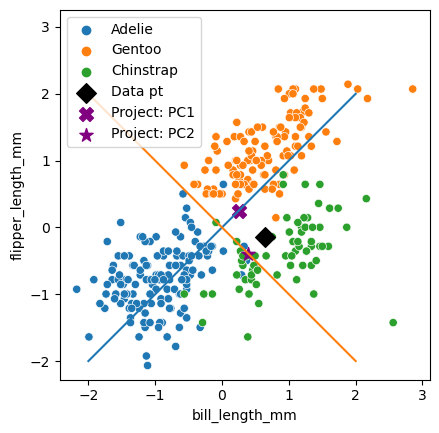

In [76]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)
plt.axis('square')

for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))

#===========
# Emphasize one point and its projections
#===========

index = 300 #<---------- play with this!

# Here's one data point
plt.scatter([penguins_subset2.iloc[index,0]],
            [penguins_subset2.iloc[index,1]], 
            marker = 'D', color = 'black', s = 100, label = 'Data pt')

# Here's the projection of that point on PC1 (X shape)
plt.scatter([X1[index]], [Y1[index]], 
           marker = 'X', color = 'purple', s = 100, label = 'Project: PC1')

# And here's the projection of that point on PC2 (star)
plt.scatter([X2[index]], [Y2[index]], 
           marker = '*', color = 'purple', s = 100, label = 'Project: PC2')

plt.legend()

Everything we just did is great for understanding what the PCA is doing, but in reality, we're usually going to be looking at the data in the transformed space. 

&#9989; **<font color=red>Do this:</font>** Make a scatter plot of PC1 and PC2. Color the points by `penguins.species`. What do you notice about how the points have moved from the (`bill`, `flipper`) scatter plot? 

<Axes: xlabel='PC1', ylabel='PC2'>

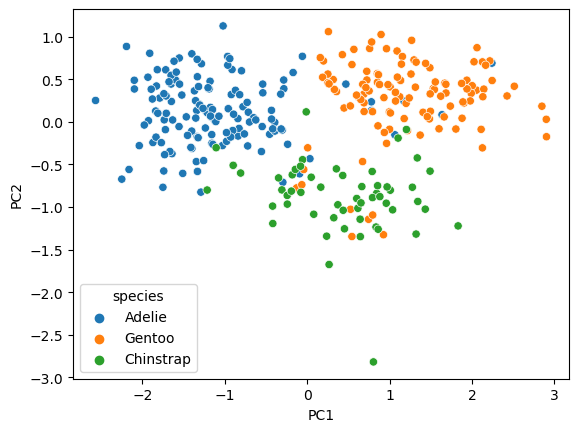

In [77]:
##ANSWER##

# Instead plot in PC1, PC2 plane 
sns.scatterplot(data = penguins_pca, x = 'PC1', y = 'PC2', hue = penguins.species)

# The points appear to have been flipped since the second PC is 
# pointing down, so now the green points are on top. 

## Penguins PCA with all columns

We used only two columns above for visualization, but we can instead use all the input columns to run our PCA. 

In [78]:
penguins_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007
1,39.5,17.4,186.0,3800.0,2007
2,40.3,18.0,195.0,3250.0,2007
4,36.7,19.3,193.0,3450.0,2007
5,39.3,20.6,190.0,3650.0,2007


In [79]:
pca = PCA(n_components=4)
penguins_pca_all = pca.fit_transform(penguins_num)
penguins_pca_all = pd.DataFrame(data = penguins_pca_all, 
                                columns = ['PC1', 'PC2', 'PC3', 'PC4'])
penguins_pca_all

,PC1,PC2,PC3,PC4
0,-457.325096,-13.376298,1.247904,-0.376474
1,-407.252228,-9.205245,-0.032667,-1.090217
2,-957.044699,8.128321,-2.491467,0.720823
3,-757.115824,1.838910,-4.880569,2.073668
4,-557.177325,-3.416994,-1.129267,2.629297
...,...,...,...,...
328,-206.895442,12.507424,9.424523,2.201716
329,-806.944216,13.443905,-1.490242,1.436737
330,-432.103210,0.999033,7.386135,-0.375741
331,-106.881363,12.241310,3.792123,2.298703


&#9989; **<font color=red>Do this:</font>** Make a scatter plot of PC1 and PC2 using this new model, and again color the points by `penguins.species`. What do you notice about how the PC plot has changed from the previous setting? 

<Axes: xlabel='PC1', ylabel='PC2'>

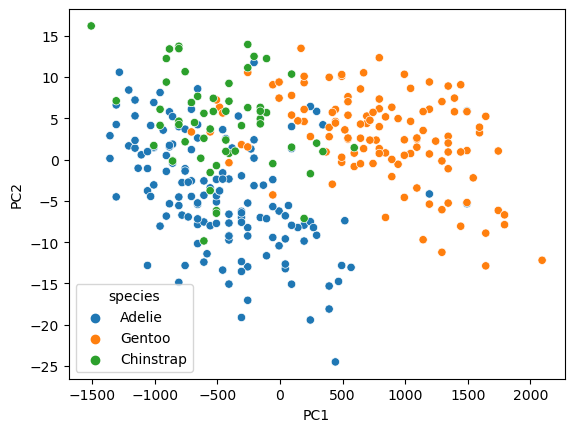

In [80]:
##ANSWER##
sns.scatterplot(data = penguins_pca_all, x = 'PC1', y = 'PC2', hue = penguins.species)

# More overlap, the projection has changed.



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh,Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.